#### Question 01 ####

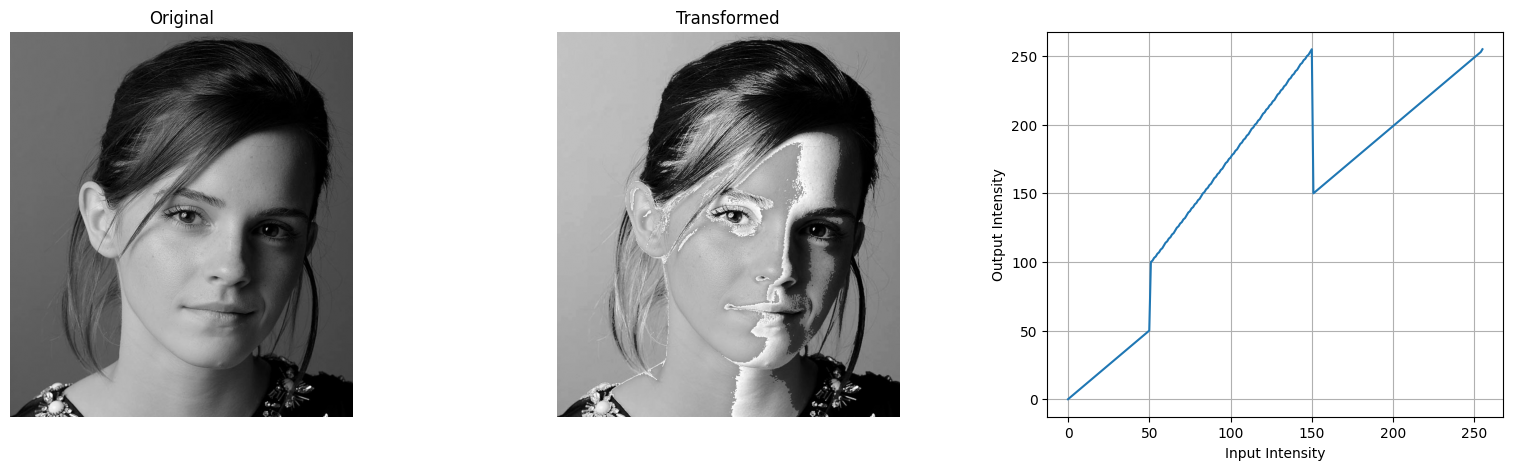

<Figure size 640x480 with 0 Axes>

In [80]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


t1 = np.linspace(0, 50, 51).astype('uint8')
t2 = np.linspace(100 , 255, 100).astype('uint8')
t3 = np.linspace(150, 255, 105).astype('uint8')

transform = np.concatenate((t1, t2), axis= 0).astype('uint8')
transform = np.concatenate((transform, t3), axis = 0).astype('uint8')


original = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
transformed = cv.LUT(original, transform)

plt.figure(figsize=(20,5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 3, 2)
plt.title("Transformed")
plt.imshow(transformed, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(np.arange(256), transform)
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()


plt.tight_layout()
plt.show()

#### Question 02 ####

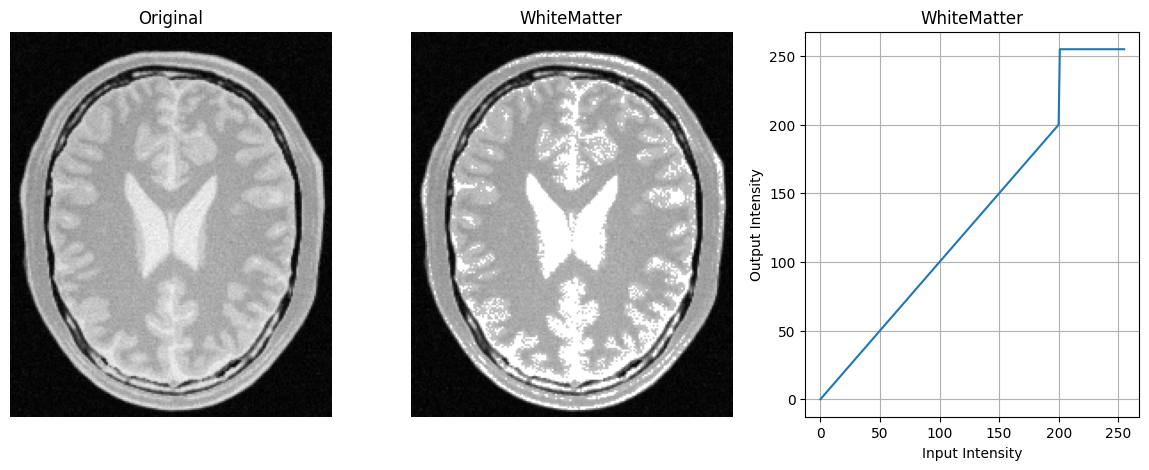

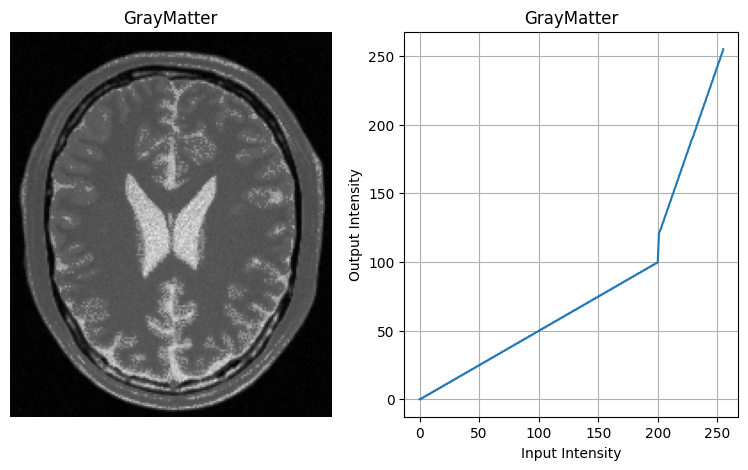

<Figure size 640x480 with 0 Axes>

In [81]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


t1 = np.linspace(0, 200, 201).astype('uint8')    # Enhance the white matters 
t2 = np.linspace(255 , 255, 55).astype('uint8')

t3 = np.linspace(0, 100, 201).astype('uint8')    # Enhance the gray matters
t4 = np.linspace(121 , 255, 55).astype('uint8')

transform_1 = np.concatenate((t1, t2), axis= 0).astype('uint8')

transform_2 = np.concatenate((t3, t4), axis= 0).astype('uint8')


original = cv.imread('images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)
GrayMatter = cv.LUT(original, transform_2)

WhiteMatter = cv.LUT(original,transform_1)

plt.figure(figsize=(25,5))
plt.subplot(1, 5, 1)
plt.title("Original")
plt.imshow(original, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 5, 2)
plt.title("WhiteMatter")
plt.imshow(WhiteMatter, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 5, 3)
plt.plot(np.arange(256), transform_1)
plt.title("WhiteMatter")
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()

plt.figure(figsize=(25,5))
plt.subplot(1, 5, 4)
plt.title("GrayMatter")
plt.imshow(GrayMatter, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 5, 5)
plt.plot(np.arange(256), transform_2)
plt.title("GrayMatter")
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()



plt.tight_layout()
plt.show()

#### Question 03 ####

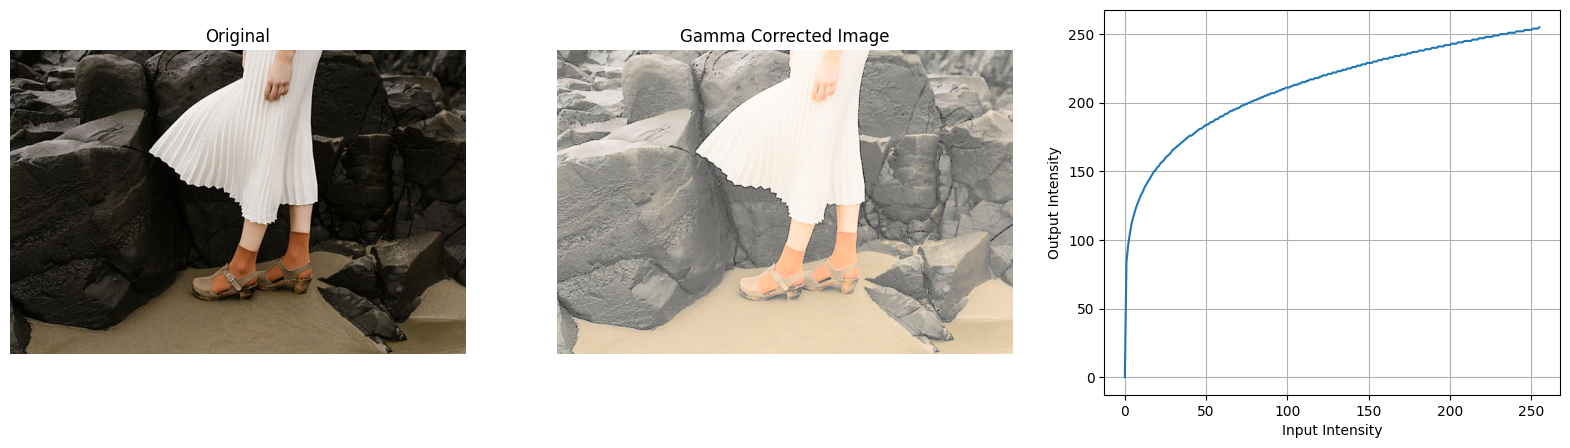

<Figure size 640x480 with 0 Axes>

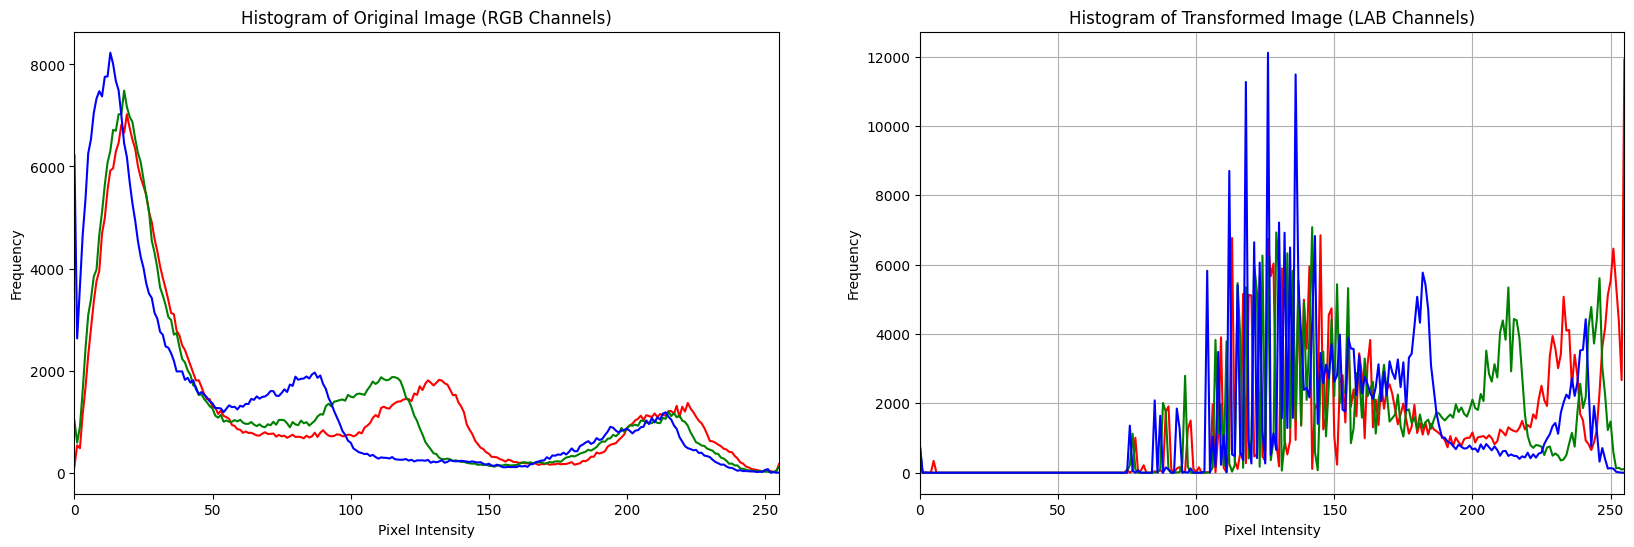

In [82]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

gamma = 0.2
original = cv.imread('images/highlights_and_shadows.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)
lab = cv.cvtColor(original, cv.COLOR_RGB2LAB)
L, a, b = cv.split(lab)
transform = np.array([(i/255)**(gamma)*255 for i in np.arange(0,256)]).astype('uint8')
L_transformed = cv.LUT(L, transform)
transformed = cv.merge([L_transformed,a,b])

corrected_image = cv.cvtColor(transformed, cv.COLOR_LAB2RGB)

plt.figure(figsize=(20,5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 3, 2)
plt.title("Gamma Corrected Image")
plt.imshow(corrected_image, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(np.arange(256), transform)
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()

plt.tight_layout()
plt.show()


colorsbgr = ('r', 'g', 'b')
colorslab = ('l', 'a', 'b')

plt.figure(figsize=(20, 6))
plt.subplot(1,2,1)
plt.title('Histogram of Original Image (RGB Channels)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

for i, col in enumerate(colorsbgr):
    hist = cv.calcHist([original], [i], None, [256], (0,256))
    plt.plot(hist, color = col)
    plt.xlim([0,255])

plt.subplot(1,2,2)
plt.title('Histogram of Transformed Image (LAB Channels)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

for i, col in enumerate(colorsbgr):
    hist = cv.calcHist([corrected_image], [i], None, [256], (0,256))
    plt.plot(hist, color = col)
    plt.xlim([0,255])

plt.grid(True)
plt.show()

#### Question 4 ####
##### a = 0.9 #####

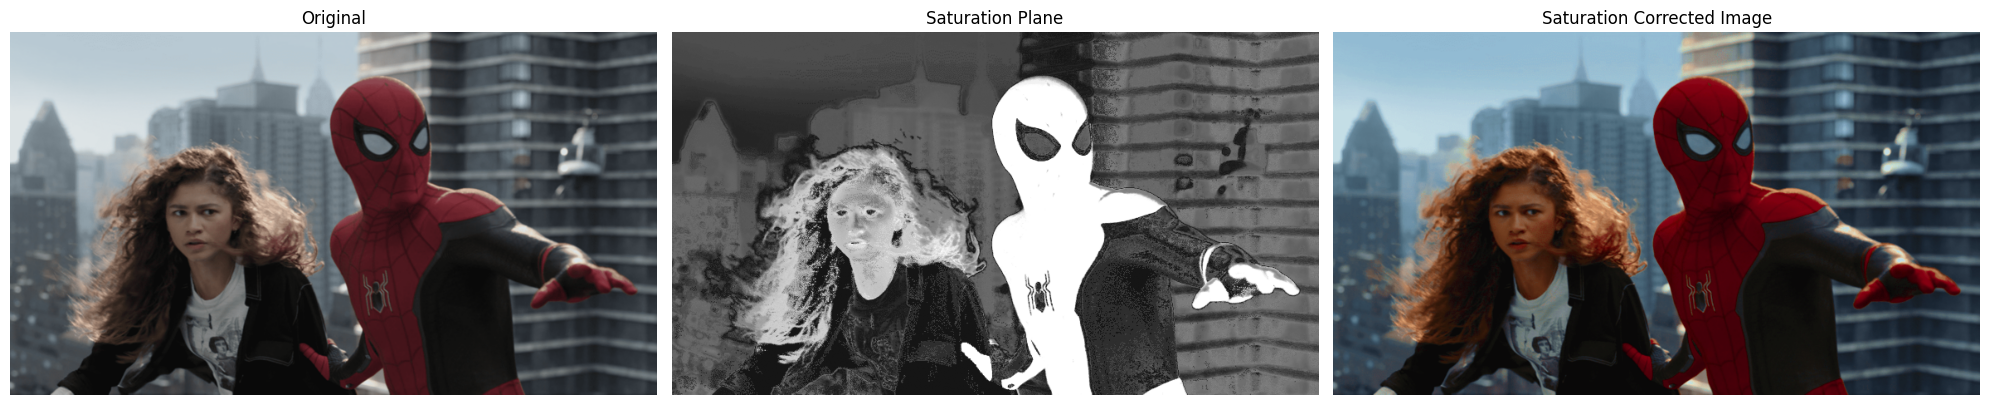

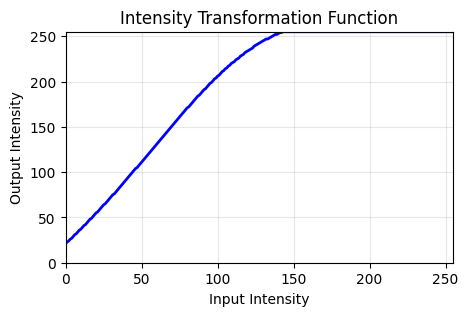

In [83]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('images/spider.png')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(original, cv.COLOR_RGB2HSV)
h, s, v = cv.split(hsv)

a = 0.9
sigma = 70
transform = np.array([
    min(i + a * 128 * np.exp(-((i - 128)**2 / (2 * sigma**2))), 255)
    for i in range(256)
]).astype('uint8')

s_transformed = cv.LUT(s, transform)
transformed = cv.merge([h, s_transformed, v])
corrected_image = cv.cvtColor(transformed, cv.COLOR_HSV2RGB)

plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Saturation Plane")
plt.imshow(s_transformed, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Saturation Corrected Image")
plt.imshow(corrected_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()


plt.figure(figsize=(5, 3))
input_values = np.arange(256)
output_values = transform
plt.plot(input_values, output_values, 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Intensity Transformation Function')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.show()


#### Question 05 ####

In [94]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('images/shells.tif', cv.IMREAD_GRAYSCALE)



#### Question 06 ####

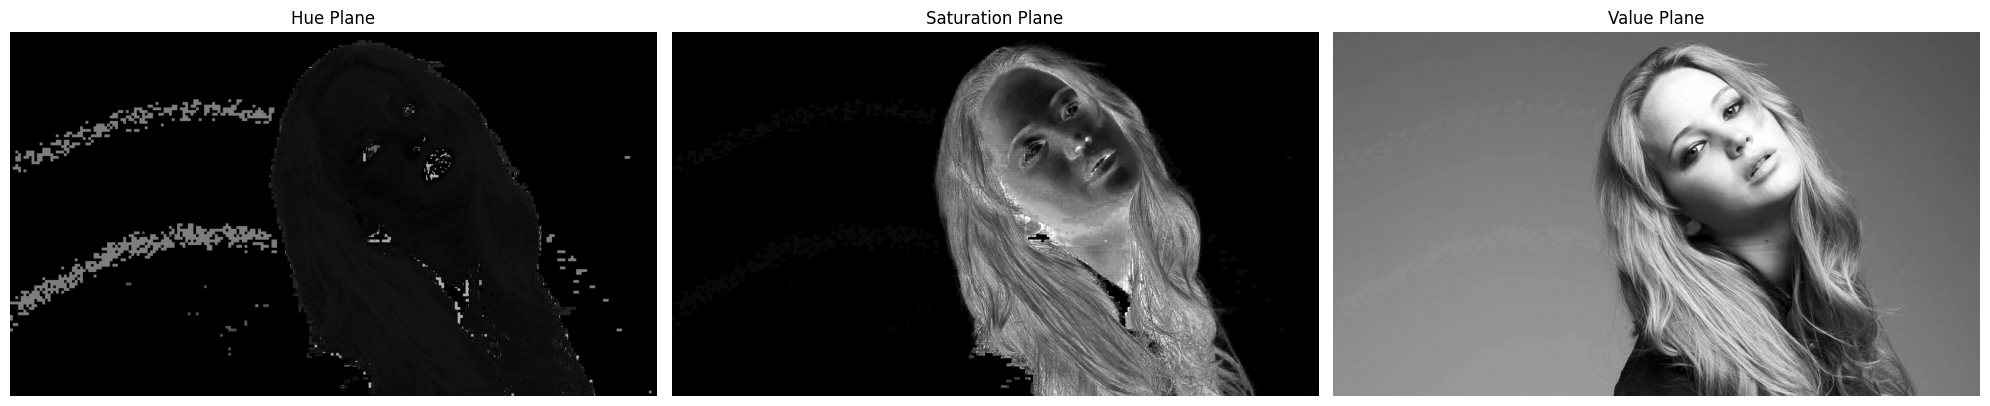

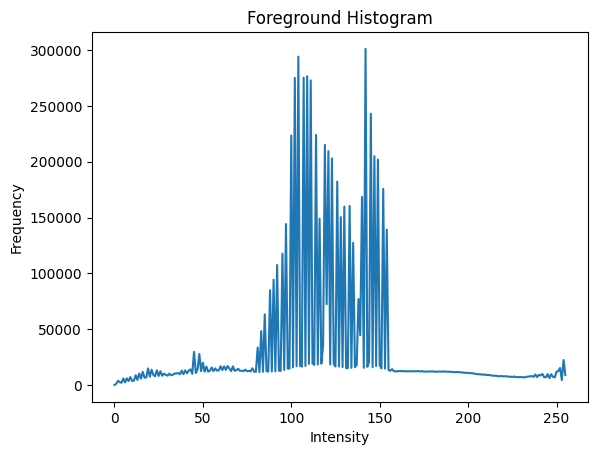

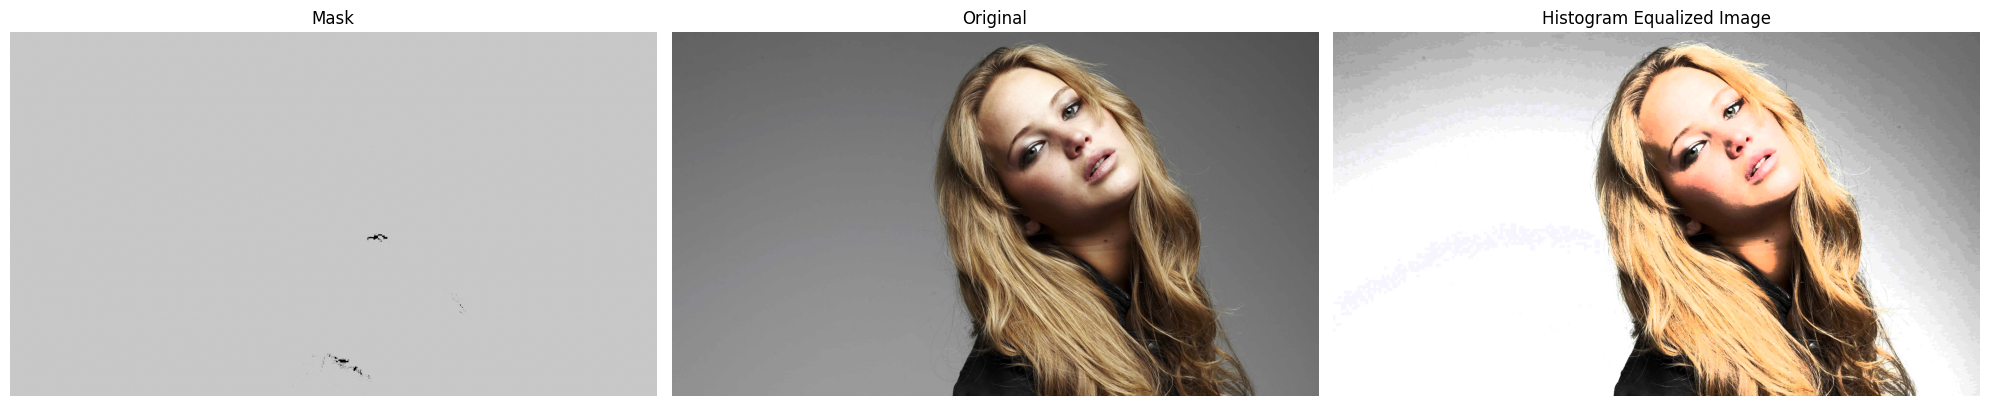

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('images/jeniffer.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(original, cv.COLOR_RGB2HSV)
h, s, v = cv.split(hsv)

plt.figure(figsize=(20,5))
plt.subplot(1, 3, 1)
plt.title("Hue Plane")
plt.imshow(h, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Saturation Plane")
plt.imshow(s, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Value Plane")
plt.imshow(v, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

_, mask = cv.threshold(v,0,200,cv.THRESH_BINARY)
foreground = cv.bitwise_and(v, v, mask=mask)
hist = cv.calcHist([foreground],[0],mask,[256],[0,256])

plt.plot(hist)
plt.title("Foreground Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

cdf = np.cumsum(hist)

L = 256
MN_f = np.sum(mask > 0) 
equalization_map = np.floor((L - 1) / MN_f * cdf).astype(np.uint8)

equalized_foreground = equalization_map[foreground]


background_mask = cv.bitwise_not(mask)
background = cv.bitwise_and(v, v, mask=background_mask)

v_combined = cv.add(background, equalized_foreground)


final_hsv = cv.merge([h, s, v_combined])
final_img = cv.cvtColor(final_hsv, cv.COLOR_HSV2RGB)

plt.figure(figsize=(20,5))
plt.subplot(1, 3, 1)
plt.title("Mask")
plt.imshow(mask, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Original")
plt.imshow(original, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Histogram Equalized Image")
plt.imshow(final_img, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()




#### Question 07 ####

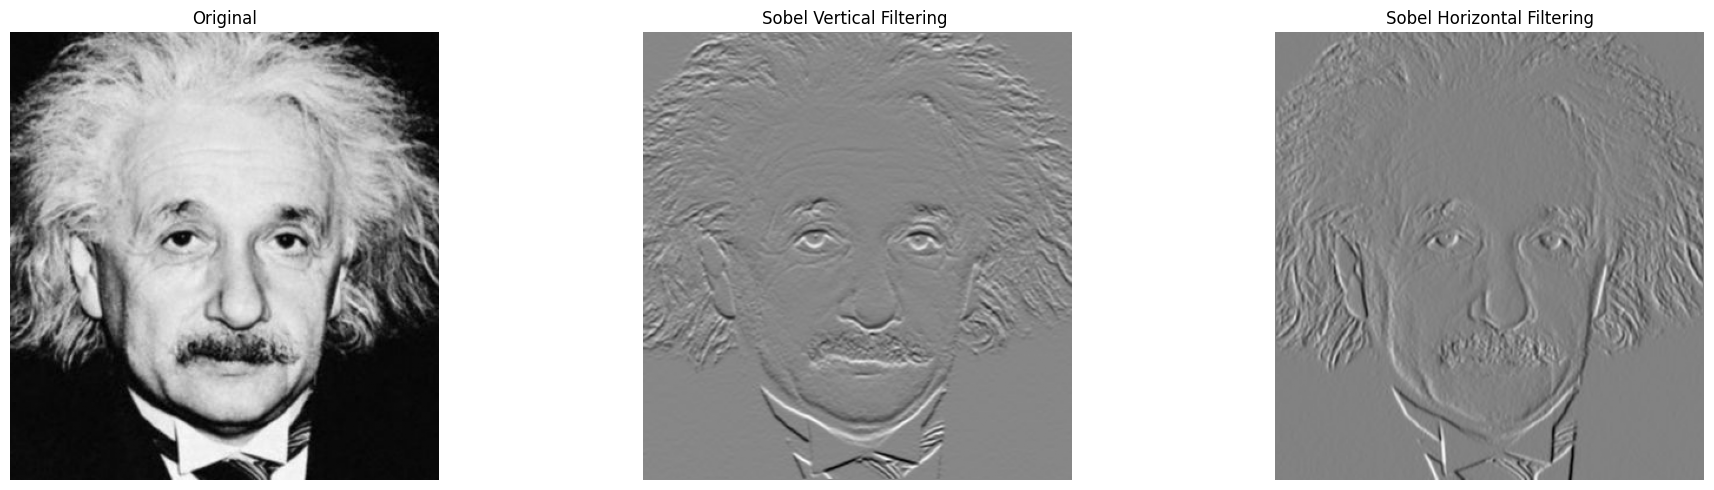

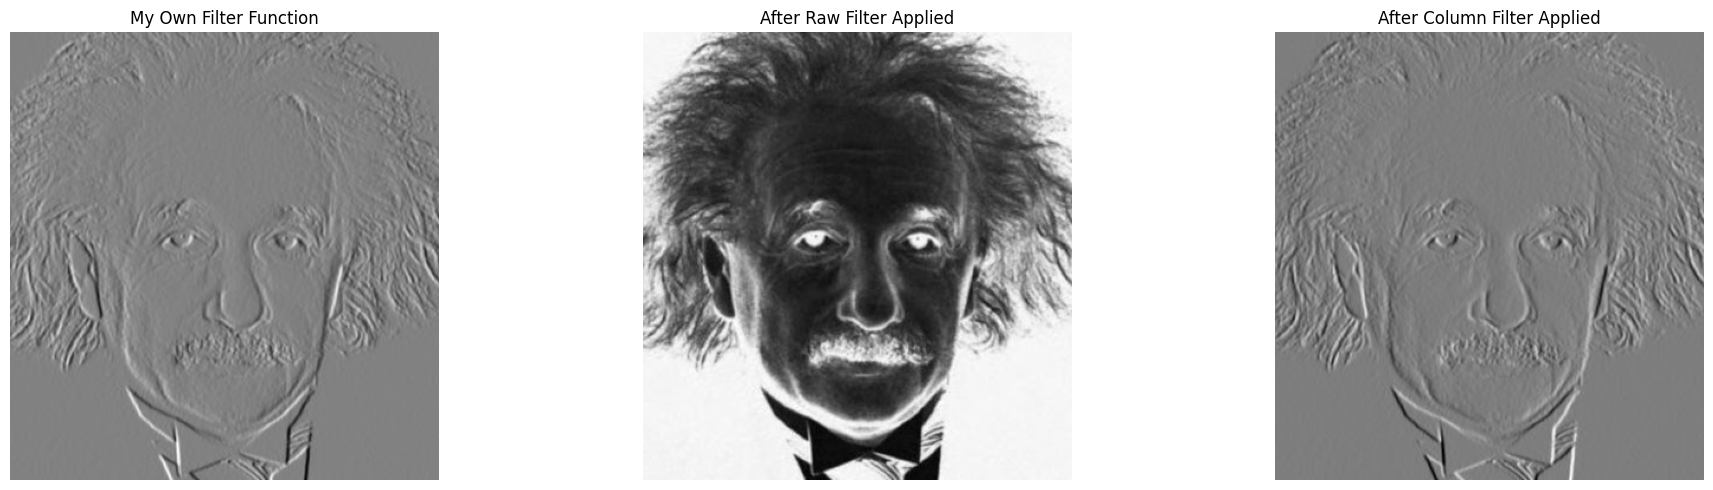

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

original = cv.imread('images/einstein.png', cv.IMREAD_GRAYSCALE)

sobel_vertical = np.array([[-1,-2,-1],[0,  0, 0],[1,  2, 1]])

sobel_horizontal = np.array([[-1,  0, 1],[-2,  0, 2],[-1,  0, 1]])

Gx = cv.filter2D(original, cv.CV_64F, sobel_vertical)
Gy = cv.filter2D(original, cv.CV_64F, sobel_horizontal)


plt.figure(figsize=(20,5)); plt.subplot(1, 3, 1); plt.title("Original"); plt.imshow(original, cmap= 'gray'); plt.axis('off')
plt.subplot(1, 3, 2); plt.title("Sobel Vertical Filtering "); plt.imshow(Gx, cmap= 'gray'); plt.axis('off')
plt.subplot(1, 3, 3); plt.title("Sobel Horizontal Filtering"); plt.imshow(Gy, cmap= 'gray'); plt.axis('off')
plt.tight_layout(); plt.show()

def filter_new (image, filter):
    m, n = image.shape
    k = len(filter)


    out_rows = m - k + 1
    out_cols = n - k + 1

    array_2d = [[0 for _ in range(out_cols)] for _ in range(out_rows)]

    for I in range(out_rows):
        for J in range(out_cols):
            total = 0
            for i in range(k):
                for j in range(k):
                    total += image[I+i][J+j] * sobel_horizontal[i][j]
            array_2d[I][J] = total

    array_2d = np.array(array_2d, dtype=np.int16)
    return array_2d

array_2d = filter_new(original,sobel_horizontal)

kernel_1 = np.array([[1, 2, 1]])
kernel_2 = np.array([1 , 0, -1]).reshape(3,1)

kernel_1applied = filter_new(original,kernel_1)
kernel_2applied = filter_new(kernel_1applied, kernel_2)

plt.figure(figsize=(20,5)); plt.subplot(1, 3, 1); plt.title("My Own Filter Function"); plt.imshow(array_2d, cmap= 'gray'); plt.axis('off')
plt.subplot(1, 3, 2); plt.title("After Raw Filter Applied"); plt.imshow(kernel_1applied, cmap= 'gray'); plt.axis('off')
plt.subplot(1, 3, 3); plt.title("After Column Filter Applied"); plt.imshow(kernel_2applied, cmap= 'gray'); plt.axis('off')
plt.tight_layout(); plt.show()


#### Question 08 ####

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


taylor = cv.imread('images/images_1/taylor.jpg', cv.IMREAD_GRAYSCALE)
taylor_small = cv.imread('images/images_1/taylor_small.jpg', cv.IMREAD_GRAYSCALE)
taylor_very_small = cv.imread('images/images_1/taylor_very_small.jpg', cv.IMREAD_GRAYSCALE)

m,n = taylor.shape

test = [[10 for i in range(5)] for i in range(3)]

scalar =4
width = len(test)
height = len(test[0])

scaled_w = width * scalar
scaled_h = height * scalar

new_array = [ [ 0 for _ in range(scaled_w)] for _ in range(scaled_h)]
print(len(new_array), len(new_array[0]))

for i in range(scaled_h):
    for j in range(scaled_w):
        i_original = i/scalar
        j_original = j/scalar

        

20 12
